# Bibliotecas

In [3]:
import os
import sys
import random
import time
import argparse
import seaborn as sns

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# Gymnasium e wrappers
import gymnasium as gym

# Stable-Baselines3
import torch
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, SubprocVecEnv, VecMonitor
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.callbacks import EvalCallback, CheckpointCallback, ProgressBarCallback

# Wrappers para customizações do LunarLander-v3

In [4]:
class RewardShapingWrapper(gym.Wrapper):
    """Reward shaping SIMPLIFICADO para LunarLander"""
    def __init__(self, env, shaping_scale=0.1):
        super().__init__(env)
        self.shaping_scale = shaping_scale
        self.step_count = 0
        # Silencioso para evitar spam

    def reset(self, **kwargs):
        self.step_count = 0
        return self.env.reset(**kwargs)

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        self.step_count += 1
        
        shaping = 0.0
        try:
            x, y, vx, vy, angle, angular_vel, leg1, leg2 = obs[:8]

            # 1. Penalizar distância horizontal (LINEAR)
            shaping -= abs(x) * 0.3

            # 2. Penalizar altura (LINEAR, não exponencial)
            shaping -= max(0, y) * 0.5
            
            # 3. Penalizar ângulo e rotação
            shaping -= (abs(angle) + abs(angular_vel)) * 0.5
            
            # 4. Recompensar descida CONTROLADA perto do solo
            if y < 0.5 and vy < 0:  # A descer perto do solo
                # Vy ideal: -0.3 a -0.5
                vel_quality = 1.0 - abs(vy + 0.4) / 0.4
                shaping += max(0, vel_quality) * 0.3
            
            # 5. Bonus moderado por aterragem
            if leg1 and leg2 and abs(x) < 0.2:
                shaping += 10.0  # REDUZIDO de 1000

            # 6. Penalizar por tempo (muito leve)
            shaping -= self.step_count * 1e-4
            
            # Escalar shaping
            shaping *= self.shaping_scale
            
        except Exception as e:
            print(f"[RewardShaping ERROR] {e}")
            shaping = 0.0
        
        return obs, reward + shaping, terminated, truncated, info

In [5]:

class WindForceWrapper(gym.Wrapper):
    """Aplica perturbação lateral (vento) à velocidade horizontal 'observada'."""
    def __init__(self, env, wind_strength=0.02, deterministic=False):
        super().__init__(env)
        self.wind_strength = wind_strength
        self.deterministic = deterministic

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        done_flag = (terminated or truncated)

        if isinstance(obs, np.ndarray) and obs.shape[0] >= 3:
            wind = self.wind_strength if self.deterministic else self.wind_strength * (2*np.random.rand()-1)
            obs = obs.copy()
            obs[2] += wind
            reward -= abs(wind) * 5.0

        # devolver no mesmo formato do original
        return obs, reward, terminated, truncated, info

In [6]:

class ObservationNoiseWrapper(gym.ObservationWrapper):
    """Add gaussian noise to observations to make the task more robust.
    """
    def __init__(self, env, noise_std=0.01):
        super().__init__(env)
        self.noise_std = noise_std


    def observation(self, observation):
        if isinstance(observation, np.ndarray):
            return observation + np.random.normal(scale=self.noise_std, size=observation.shape)
        return observation

In [7]:

class ActionSmoothingWrapper(gym.ActionWrapper):
    """
    Suaviza as ações usando média móvel exponencial (EMA) para reduzir oscilações.
    Útil para estabilizar o controle durante o pouso.
    """
    def __init__(self, env, smoothing_factor=0.3):
        super().__init__(env)
        self.smoothing_factor = smoothing_factor  # alpha para EMA (0-1)
        self.previous_action = None

    def reset(self, **kwargs):
        self.previous_action = None
        return self.env.reset(**kwargs)

    def action(self, action):
        """
        Aplica suavização exponencial: 
        smoothed_action = alpha * current_action + (1-alpha) * previous_action
        """
        if self.previous_action is None:
            # Primeira ação do episódio, sem suavização
            self.previous_action = action
            return action
        
        # Aplicar EMA
        smoothed_action = (self.smoothing_factor * action + 
                          (1 - self.smoothing_factor) * self.previous_action)
        
        # Arredondar para inteiro (ações discretas: 0, 1, 2, 3)
        smoothed_action = int(np.round(np.clip(smoothed_action, 0, 3)))
        
        self.previous_action = smoothed_action
        return smoothed_action


# Criação do ambiente customizado

In [8]:
def make_env_factory(env_id='LunarLander-v3', seed=None, config_name='orig', monitor_dir=None):
    """
    Retorna uma função _init compatível com DummyVecEnv que:
     - cria env,
     - aplica wrappers consoante config_name,
     - envolve com Monitor(escreve monitor.csv em monitor_dir).
    config_name em {'orig', 'reward', 'wind', 'noise', 'all'}
    """
    def _init():
        env = gym.make(env_id)
        if seed is not None:
            # seed reset (Gymnasium)
            try:
                env.reset(seed=seed)
            except TypeError:
                env.reset()
            env.action_space.seed(seed)
            env.observation_space.seed(seed)

        # Aplicar wrappers conforme config 
        if 'reward' in config_name:
            env = RewardShapingWrapper(env)
        if 'wind' in config_name:
            env = WindForceWrapper(env, wind_strength=0.01, deterministic=False)
        if 'noise' in config_name:
            env = ObservationNoiseWrapper(env, noise_std=0.02)
        if 'smooth' in config_name:
            env = ActionSmoothingWrapper(env, smoothing_factor=0.3)
        if config_name == 'all':
            env = RewardShapingWrapper(env)
            env = WindForceWrapper(env, wind_strength=0.03, deterministic=False)
            env = ObservationNoiseWrapper(env, noise_std=0.02)
            env = ActionSmoothingWrapper(env, smoothing_factor=0.3)
        # caso 'orig' => nenhum wrapper

        # Monitor: grava os episódios neste ficheiro
        if monitor_dir is not None:
            os.makedirs(monitor_dir, exist_ok=True)
            monitor_file = os.path.join(monitor_dir, 'monitor.csv')
            env = Monitor(env, filename=monitor_file)
        else:
            env = Monitor(env)



        return env    
    return _init

In [9]:
def make_env_factory_multiple_configs(env_id='LunarLander-v3', seed=None, config_name='orig', monitor_dir=None):
    """
    Retorna uma função _init compatível com DummyVecEnv que:
     - cria env,
     - aplica wrappers consoante config_name,
     - envolve com Monitor(escreve monitor.csv em monitor_dir).
    config_name em {'orig', 'reward', 'wind', 'noise', 'all'}
    """
    def _init():
        env = gym.make(env_id)
        if seed is not None:
            # seed reset (Gymnasium)
            try:
                env.reset(seed=seed)
            except TypeError:
                env.reset()
            env.action_space.seed(seed)
            env.observation_space.seed(seed)

        # Aplicar wrappers conforme config
        if 'reward' in config_name:
            print("[CREATING ENV] Applying RewardShapingWrapper")
            env = RewardShapingWrapper(env)
        if 'wind' in config_name:
            print("[CREATING ENV] Applying WindForceWrapper")
            env = WindForceWrapper(env, wind_strength=0.01, deterministic=False)
        if 'noise' in config_name:
            print("[CREATING ENV] Applying ObservationNoiseWrapper")
            env = ObservationNoiseWrapper(env, noise_std=0.02)
        if 'smooth' in config_name:
            print("[CREATING ENV] Applying ActionSmoothingWrapper")
            env = ActionSmoothingWrapper(env, smoothing_factor=0.3)
        if config_name == 'all':
            print("[CREATING ENV] Applying ALL wrappers")
            env = RewardShapingWrapper(env)
            env = WindForceWrapper(env, wind_strength=0.03, deterministic=False)
            env = ObservationNoiseWrapper(env, noise_std=0.02)
            env = ActionSmoothingWrapper(env, smoothing_factor=0.3)
        
        # caso 'orig' => nenhum wrapper
        
        # Monitor: grava os episódios neste ficheiro
        if monitor_dir is not None:
            os.makedirs(monitor_dir, exist_ok=True)
            monitor_file = os.path.join(monitor_dir, 'monitor.csv')
            env = Monitor(env, filename=monitor_file)
        else:
            env = Monitor(env)



        return env    
    return _init

# Função de treino do PPO

In [10]:
def train_configs(
    config_name='orig',
    seed=0,
    timesteps=300_000,
    hyperparams=None,
    out_dir='./experiments',
    name='experiment',
    n_envs=4,
    verbose=1,
    silent=False
):
    """
    Treina um PPO para a configuração especificada.
    """
    import os
    import random
    import numpy as np
    import torch

    from stable_baselines3 import PPO
    from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor
    from stable_baselines3.common.callbacks import (
        EvalCallback,
        CheckpointCallback,
        ProgressBarCallback,
    )

    if hyperparams is None:
        hyperparams = {}

    os.makedirs(out_dir, exist_ok=True)

    # GPU auto-detect
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    if not silent:
        hp_str = f"{len(hyperparams)} params" if hyperparams else "defaults"
        print(
            f"\n🔧 Training: {timesteps:,} steps | "
            f"{device.upper()} | {n_envs} envs | {hp_str}"
        )

    # Reprodutibilidade
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    vec_env = None
    eval_env = None

    try:
        # ===== Envs paralelos =====
        env_fns = [
            make_env_factory(
                seed=seed + i,
                config_name=config_name,
                monitor_dir=out_dir,
            )
            for i in range(n_envs)
        ]

        vec_env = DummyVecEnv(env_fns)
        vec_env = VecMonitor(vec_env)

        # ===== Policy =====
        policy_kwargs = dict(
            activation_fn=torch.nn.Tanh,
            net_arch=[dict(pi=[256, 256], vf=[256, 256])],
        )

        # ===== PPO defaults =====
        ppo_defaults = dict(
            policy='MlpPolicy',
            env=vec_env,
            verbose=0 if silent else verbose,
            seed=seed,
            learning_rate=1e-4,
            n_steps=2048,
            batch_size=64,
            n_epochs=10,
            gamma=0.99,
            gae_lambda=0.95,
            ent_coef=0.01,
            vf_coef=0.5,
            clip_range=0.2,
            policy_kwargs=policy_kwargs,
            tensorboard_log=None if silent else os.path.join(out_dir, 'tb'),
            device=device,
        )

        # Override com hiperparâmetros fornecidos
        ppo_defaults.update(hyperparams)

        model = PPO(**ppo_defaults)

        # ===== Eval env =====
        eval_env = DummyVecEnv([
            make_env_factory(
                seed=seed + 10_000,
                config_name=config_name,
                monitor_dir=None,
            )
        ])
        eval_env = VecMonitor(eval_env)

        eval_callback = EvalCallback(
            eval_env,
            best_model_save_path=out_dir,
            log_path=out_dir,
            eval_freq=max(10_000, ppo_defaults['n_steps'] * 2),
            n_eval_episodes=5,
            deterministic=True,
            render=False,
            verbose=0 if silent else 1,
        )

        checkpoint_callback = CheckpointCallback(
            save_freq=max(50_000, ppo_defaults['n_steps'] * 5),
            save_path=out_dir,
            name_prefix='ppo_checkpoint',
            verbose=0 if silent else 2,
        )

        callbacks = [eval_callback, checkpoint_callback]

        if not silent:
            callbacks.append(ProgressBarCallback())

        # ===== Treino =====
        model.learn(
            total_timesteps=timesteps,
            callback=callbacks,
            progress_bar=not silent,
        )

        model_path = os.path.join(out_dir, f'ppo_{name}_seed{seed}.zip')
        model.save(model_path)

        if not silent:
            print("✅ Model saved\n")

        return model_path, out_dir

    finally:
        # Garantir encerramento correto
        if vec_env is not None:
            vec_env.close()
        if eval_env is not None:
            eval_env.close()


# Função de avaliação com critério revisado

In [11]:
def evaluate_custom(model_path, config_name='orig', seed=None, episodes=50, silent=False):
    """
    Avalia o modelo (usa DummyVecEnv com mesma config).
    Critério de sucesso:
      - em qualquer step do episódio both legs touched, OR total_reward >= 200
    Retorna dicionário com métricas e lista de recompensas por episódio.
    """
    import numpy as np
    from stable_baselines3 import PPO
    from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor
    from stable_baselines3.common.evaluation import evaluate_policy
    from tqdm import tqdm

    vec_env = None

    try:
        # carregar env (para avaliação, monitor não é necessário)
        env_fn = make_env_factory(
            seed=seed,
            config_name=config_name,
            monitor_dir=None
        )
        vec_env = DummyVecEnv([env_fn])
        vec_env = VecMonitor(vec_env)

        model = PPO.load(model_path, env=vec_env)

        # avaliação rápida
        mean_reward, std_reward = evaluate_policy(
            model,
            vec_env,
            n_eval_episodes=min(10, episodes),
            deterministic=True
        )

        if not silent:
            print(f"[EVAL] quick evaluate_policy: mean={mean_reward:.2f} std={std_reward:.2f}")

        successes = 0
        crashes = 0
        rewards = []
        episode_lengths = []

        episode_iterator = (
            range(episodes)
            if silent
            else tqdm(range(episodes), desc="Evaluating episodes", unit="ep")
        )

        for _ in episode_iterator:
            reset_out = vec_env.reset()
            obs = reset_out[0] if isinstance(reset_out, tuple) else reset_out

            done = False
            total_r = 0.0
            steps = 0
            landed_flag = False

            while not done:
                action, _ = model.predict(obs, deterministic=True)
                obs, reward, done, info = vec_env.step(action)
                steps += 1

                try:
                    total_r += float(np.array(reward).item())
                except Exception:
                    total_r += float(reward)

                try:
                    last_obs = obs[0]  # DummyVecEnv usa batch dimension
                    if bool(last_obs[6]) and bool(last_obs[7]):
                        landed_flag = True
                except Exception:
                    pass

            if landed_flag or total_r >= 200:
                successes += 1
            elif total_r < -100:
                crashes += 1

            rewards.append(total_r)
            episode_lengths.append(steps)

        rewards = np.array(rewards)
        episode_lengths = np.array(episode_lengths)

        result = {
            'mean_reward': float(rewards.mean()),
            'std_reward': float(rewards.std()),
            'median_reward': float(np.median(rewards)),
            'min_reward': float(rewards.min()),
            'max_reward': float(rewards.max()),
            'success_rate': float(successes) / len(rewards),
            'crash_rate': float(crashes) / len(rewards),
            'mean_episode_length': float(episode_lengths.mean()),
            'std_episode_length': float(episode_lengths.std()),
            'per_episode': rewards,
        }

        if not silent:
            print(
                f"📊 Eval: {result['mean_reward']:.1f}±{result['std_reward']:.1f} | "
                f"Success: {result['success_rate']:.1%} | {episodes} eps"
            )

        return result

    finally:
        # Garantir que ambiente fecha mesmo com erros
        if vec_env is not None:
            vec_env.close()


# Função para plot de treino

In [12]:
def plot_training_monitor(monitor_csv_path, window=10, show=True, out_png=None):
    """Plota rewards (raw + smoothed) a partir do monitor.csv gerado pelo Monitor."""
    if not os.path.exists(monitor_csv_path):
        print("[PLOT] monitor file not found:", monitor_csv_path)
        return
    
    fig = None
    try:
        # Carregar dados com tratamento de erros
        try:
            df = pd.read_csv(monitor_csv_path, comment='#')
        except Exception as e:
            print(f"[PLOT ERROR] Failed to read CSV: {e}")
            return
        
        if df.empty or 'r' not in df.columns:
            print("[PLOT ERROR] CSV is empty or missing 'r' column")
            return
        
        # Calcular smoothing
        df['r_smooth'] = df['r'].rolling(window=window, min_periods=1).mean()
        
        # Criar figura
        fig = plt.figure(figsize=(12, 5))
        
        # Plot raw rewards (cinza transparente)
        plt.plot(df['r'], alpha=0.2, color='gray', linewidth=0.8, label='Raw rewards')
        
        # Plot smoothed rewards (azul destacado)
        plt.plot(df['r_smooth'], color='#2E86DE', linewidth=2.5, label=f'Smoothed (window={window})')
        
        # Linha de referência em y=0
        plt.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Target (0)')
        
        # Adicionar linha de referência em y=200 (sucesso)
        plt.axhline(y=200, color='green', linestyle='--', linewidth=1, alpha=0.5, label='Success (200)')
        
        # Labels e título
        plt.xlabel('Episode', fontsize=12, fontweight='bold')
        plt.ylabel('Reward', fontsize=12, fontweight='bold')
        
        # Título com estatísticas
        config_name = os.path.basename(os.path.dirname(monitor_csv_path))
        mean_reward = df['r'].mean()
        final_avg = df['r_smooth'].iloc[-50:].mean() if len(df) >= 50 else df['r_smooth'].mean()
        plt.title(f'{config_name} | Mean: {mean_reward:.1f} | Final 50 eps avg: {final_avg:.1f}',
                 fontsize=13, fontweight='bold', pad=15)
        
        # Grid e legend
        plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
        plt.legend(loc='lower right', fontsize=10, framealpha=0.9)
        
        # Ajustar layout
        plt.tight_layout()
        
        # Salvar se especificado
        if out_png:
            plt.savefig(out_png, dpi=150, bbox_inches='tight')
            print(f"[PLOT] ✅ Saved to {out_png}")
        
        # Mostrar se especificado
        if show:
            plt.show()
            
    except Exception as e:
        print(f"[PLOT ERROR] Unexpected error: {e}")
        
    finally:
        # Garantir fechamento da figura
        if fig is not None:
            plt.close(fig)

def plot_compare_configs(base_dir, configs, seed, window=20):
    """Plota curvas suavizadas (por seed) comparando várias configs no mesmo gráfico."""
    plt.figure(figsize=(10,5))
    for cfg in configs:
        monitor_csv = os.path.join(base_dir, cfg, f'seed{seed}', 'monitor.csv')
        if not os.path.exists(monitor_csv):
            print("[COMPARE] monitor not found for", cfg, "seed", seed)
            continue
        df = pd.read_csv(monitor_csv, comment='#')
        df['r_smooth'] = df['r'].rolling(window=window, min_periods=1).mean()
        plt.plot(df['r_smooth'], label=f'{cfg}')
    plt.xlabel('Episode')
    plt.ylabel('Smoothed Reward')
    plt.title(f'Compare configs (seed {seed})')
    plt.legend()
    plt.show()

# Execução para múltiplas seeds

In [13]:
def run_experiments(
    configs,
    seeds,
    timesteps=50_000,
    hyperparams=None,
    out_dir='./experiments',
    name='experiment'
):
    """
    Roda treinos e avaliações para lista de configs e seeds.
    Retorna: results[config][seed] = metrics
    """
    results = {}

    for config in configs:
        results[config] = {}

        for seed in seeds:
            print("\n============================")
            print(f"Training config={config} seed={seed}")

            model_path, run_dir = train_configs(
                config_name=config,
                seed=seed,
                timesteps=timesteps,
                hyperparams=hyperparams,
                out_dir=out_dir,
                name=name
            )

            print(f"Evaluating model for config={config} seed={seed}")

            metrics = evaluate_custom(
                model_path=model_path,
                config_name=config,
                seed=seed,
                episodes=50
            )

            results[config][seed] = metrics

    return results


In [14]:
from itertools import product

def run_hyperparam_grid(config_name, seed, grid, timesteps=300_000, out_root='./experiments_grid'):
    """
    grid: dict of lists, e.g. {'learning_rate':[3e-5,1e-4],'n_steps':[2048,4096]}
    Vai gerar todas as combinações, treinar e guardar resultados em out_root/config_name/seed/hparam_i
    Retorna lista de (hparam_dict, metrics)
    """
    keys, values = zip(*grid.items())
    combos = [dict(zip(keys, v)) for v in product(*values)]
    results = []
    for i, combo in enumerate(combos):
        print(f"\n---- Grid {i+1}/{len(combos)}: {combo}")
        # colocar cada combo numa subpasta
        out_root_combo = os.path.join(out_root, config_name, f'seed{seed}', f'grid_{i}')
        os.makedirs(out_root_combo, exist_ok=True)
        model_path, _ = train_configs(config_name=config_name, seed=seed, timesteps=timesteps,
                                    hyperparams=combo, out_root=out_root_combo)
        metrics = evaluate_custom(model_path=model_path, config_name=config_name, seed=seed, episodes=30)
        results.append((combo, metrics, model_path, out_root_combo))
    return results


In [15]:
def run_hyperparam_grid_optimized(
    config_name,
    seed,
    grid,
    timesteps=300_000,
    out_root='./experiments_grid',
    top_k=3,
    early_stop_reward=250,
    early_stop_success=0.99
):
    """
    Grid search OTIMIZADO com tracking de melhores modelos.
    """
    import os
    from itertools import product

    keys, values = zip(*grid.items())
    combos = [dict(zip(keys, v)) for v in product(*values)]

    results = []
    best_results = []

    print("\n" + "=" * 60)
    print("HYPERPARAMETER OPTIMIZATION")
    print(f"Total combinations: {len(combos)}")
    print("=" * 60 + "\n")

    for i, combo in enumerate(combos):
        print("\n" + "=" * 60)
        print(f"[{i + 1}/{len(combos)}] Testing: {combo}")
        print("=" * 60)

        out_root_combo = os.path.join(
            out_root,
            config_name,
            f'seed{seed}',
            f'grid_{i}'
        )
        os.makedirs(out_root_combo, exist_ok=True)

        try:
            # ===== Treino =====
            model_path, _ = train_configs(
                config_name=config_name,
                seed=seed,
                timesteps=timesteps,
                hyperparams=combo,
                out_dir=out_root_combo,
                name=f'grid_{i}',
                verbose=0,
                silent=True
            )

            # ===== Avaliação =====
            metrics = evaluate_custom(
                model_path=model_path,
                config_name=config_name,
                seed=seed,
                episodes=50,
                silent=True
            )

            score = metrics['mean_reward'] + metrics['success_rate'] * 100

            result = {
                'combo': combo,
                'metrics': metrics,
                'model_path': model_path,
                'out_dir': out_root_combo,
                'score': score
            }

            results.append(result)

            print("\n📊 RESULTS:")
            print(f"  Mean Reward:   {metrics['mean_reward']:.2f}")
            print(f"  Success Rate:  {metrics['success_rate']:.2%}")
            print(f"  Combined Score:{score:.2f}")

            # ===== Atualizar TOP-K =====
            best_results.append(result)
            best_results.sort(key=lambda x: x['score'], reverse=True)
            best_results = best_results[:top_k]

            print(f"\n🏆 CURRENT TOP {top_k}:")
            for idx, res in enumerate(best_results, 1):
                print(
                    f"  #{idx} | Score={res['score']:.2f} | "
                    f"Reward={res['metrics']['mean_reward']:.2f} | "
                    f"Success={res['metrics']['success_rate']:.2%}"
                )

            # ===== Early stopping =====
            if early_stop_reward is not None and early_stop_success is not None:
                if (
                    metrics['mean_reward'] >= early_stop_reward
                    and metrics['success_rate'] >= early_stop_success
                ):
                    print("\n" + "=" * 60)
                    print("🎯 EARLY STOPPING TRIGGERED!")
                    print("=" * 60)
                    print(f"Reward:  {metrics['mean_reward']:.1f} >= {early_stop_reward}")
                    print(f"Success: {metrics['success_rate']:.1%} >= {early_stop_success:.1%}")
                    print(f"Stopped at grid {i + 1}/{len(combos)}")
                    print("=" * 60 + "\n")
                    break

        except Exception as e:
            print(f"\n❌ ERROR training combo {i + 1}: {e}")
            continue

    # ===== Resultado final =====
    print("\n" + "=" * 60)
    print(f"🎯 FINAL TOP {top_k} HYPERPARAMETERS")
    print("=" * 60 + "\n")

    for idx, res in enumerate(best_results, 1):
        print("=" * 60)
        print(f"#{idx} - Score: {res['score']:.2f}")
        print("Hyperparameters:")
        for k, v in res['combo'].items():
            print(f"  - {k}: {v}")

        print("\nMetrics:")
        print(f"  - Mean Reward:  {res['metrics']['mean_reward']:.2f}")
        print(f"  - Success Rate:{res['metrics']['success_rate']:.2%}")
        print(f"  - Model Path:  {res['model_path']}")
        print("=" * 60 + "\n")

    return best_results, results


In [16]:
def run_random_search(config_name, seed, param_distributions, n_trials=20, timesteps=300_000, 
                      out_root='./experiments_random', early_stop_reward=250, early_stop_success=0.99):
    """
    Random Search: mais eficiente que Grid Search.
    
    Args:
        param_distributions: dict com ranges, ex:
            {
                'learning_rate': (1e-5, 1e-3, 'log'),  # log-uniform
                'n_steps': [1024, 2048, 4096],         # choice
                'batch_size': (32, 128, 'int'),        # uniform int
                'ent_coef': (0.0, 0.1, 'uniform')      # uniform float
            }
        n_trials: número de combinações aleatórias a testar
        early_stop_reward: threshold de reward para parar busca (None = desativado)
        early_stop_success: threshold de success rate para parar busca (None = desativado)
    """
    import random as rand
    import traceback
    
    # CRUCIAL: Seed diferente para cada trial
    np.random.seed(None)  # Reset seed para ter aleatoriedade
    rand.seed(None)
    
    def sample_param(distribution, trial_num):
        """Amostra um parâmetro da distribuição com seed baseada no trial"""
        # Seed única para cada trial (usa seed base + trial number)
        local_seed = seed + trial_num + int(time.time() * 1000) % 10000
        rand.seed(local_seed)
        np.random.seed(local_seed)
        
        if isinstance(distribution, list):
            # Choice
            return rand.choice(distribution)
        elif isinstance(distribution, tuple):
            low, high, dist_type = distribution
            if dist_type == 'log':
                return 10 ** rand.uniform(np.log10(low), np.log10(high))
            elif dist_type == 'int':
                return rand.randint(int(low), int(high))
            elif dist_type == 'uniform':
                return rand.uniform(low, high)
        return distribution
    
    results = []
    best_score = -float('inf')
    best_combo = None
    
    print(f"\n{'='*60}")
    print(f"🔍 RANDOM SEARCH OPTIMIZATION")
    print(f"{'='*60}")
    print(f"Trials: {n_trials} | Timesteps: {timesteps:,}\n")
    
    for trial in range(n_trials):
        # Sample hyperparameters com seed única para cada trial
        combo = {key: sample_param(dist, trial) for key, dist in param_distributions.items()}
        
        print(f"\n{'─'*60}")
        print(f"🧪 Trial {trial+1}/{n_trials}")
        # Mostrar TODOS os parâmetros
        for k, v in combo.items():
            val_str = f"{v:.6f}" if isinstance(v, float) else str(v)
            print(f"  {k:15s}: {val_str}")
        
        # Treinar
        out_dir = os.path.join(out_root, config_name, f'seed{seed}', f'trial_{trial}')
        os.makedirs(out_dir, exist_ok=True)
        
        try:
            model_path, _ = train_configs(
                config_name=config_name,
                seed=seed,
                timesteps=timesteps,
                hyperparams=combo,
                out_dir=out_dir,
                name=f'trial_{trial}',
                verbose=0,
                silent=True
            )
            
            print(f"🧬 Evaluating...", end=" ")
            metrics = evaluate_custom(model_path, config_name, seed, episodes=50, silent=True)
            score = metrics['mean_reward'] + metrics['success_rate'] * 100
            
            results.append({
                'combo': combo,
                'metrics': metrics,
                'score': score,
                'model_path': model_path
            })
            
            # Status badge
            is_best = score > best_score
            badge = "🏆 NEW BEST!" if is_best else ""
            
            print(f"\n📊 Score: {score:.1f} | Reward: {metrics['mean_reward']:.1f} | Success: {metrics['success_rate']:.1%} {badge}")
            
            if is_best:
                best_score = score
            # Early stopping: verificar se atingiu thresholds
            if early_stop_reward is not None and early_stop_success is not None:
                if metrics['mean_reward'] >= early_stop_reward and metrics['success_rate'] >= early_stop_success:
                    print(f"\n\n{'='*60}")
                    print(f"🎯 EARLY STOPPING TRIGGERED!")
                    print(f"{'='*60}")
                    print(f"  Reward: {metrics['mean_reward']:.1f} >= {early_stop_reward}")
                    print(f"  Success: {metrics['success_rate']:.1%} >= {early_stop_success:.1%}")
                    print(f"  Stopping at trial {trial+1}/{n_trials}")
                    print(f"{'='*60}\n")
                    break
            
        except Exception as e:
            print(f"\n❌ ERROR: {str(e)[:80]}")
            continue
    
    # Ordenar resultados
    results.sort(key=lambda x: x['score'], reverse=True)
    
    # Se nenhum trial foi bem-sucedido
    if best_combo is None:
        print("\n⚠ Nenhum trial concluído com sucesso. Verifica os erros acima.")
        return results
    
    # Resultado final
    print(f"\n\n{'='*60}")
    print(f"🎯 BEST HYPERPARAMETERS (Score: {best_score:.1f})")
    print(f"{'='*60}")
    for k, v in best_combo.items():
        val_str = f"{v:.6f}" if isinstance(v, float) else str(v)
        print(f"  {k:15s}: {val_str}")
    print(f"{'='*60}\n")
    
    return results


Pipeline em 4 fases: Random Search → Grid Search → Validação Multi-Seed → Análise Final

In [17]:
def hyperparameter_optimization_pipeline(
    config_name='reward',
    n_random_trials=30,
    timesteps_phase1=200_000,
    timesteps_phase2=300_000,
    timesteps_phase3=500_000,
    out_root='./hpo_pipeline',
    early_stop_reward=250,
    early_stop_success=0.99
):
    """
    Pipeline completo de otimização de hiperparâmetros em 4 fases.
    
    Args:
        early_stop_reward: threshold de reward para early stopping (None = desativado)
        early_stop_success: threshold de success rate para early stopping (None = desativado)
    """
    import json

    os.makedirs(out_root, exist_ok=True)

    print("\n" + "=" * 80)
    print("🎯 HYPERPARAMETER OPTIMIZATION PIPELINE")
    print("=" * 80)
    print(f"📁 Config: {config_name}")
    print(f"🔬 Phase 1: Random Search ({n_random_trials} trials × {timesteps_phase1:,} steps)")
    print(f"🎯 Phase 2: Grid Search Refinement ({timesteps_phase2:,} steps)")
    print(f"✅ Phase 3: Multi-seed Validation ({timesteps_phase3:,} steps)")
    print(f"💾 Output: {out_root}")
    print("=" * 80 + "\n")

    # ======================================================================
    # FASE 1 — RANDOM SEARCH
    # ======================================================================
    print("\n🔍 " + "=" * 76)
    print("PHASE 1: RANDOM SEARCH - Wide Exploration")
    print("=" * 80)

    param_distributions = {
        'learning_rate': (5e-6, 1e-3, 'log'),
        'n_steps': [1024, 2048, 4096, 8192],
        'batch_size': [32, 64, 128, 256],
        'n_epochs': (5, 20, 'int'),
        'gamma': (0.95, 0.9999, 'uniform'),
        'gae_lambda': (0.85, 0.99, 'uniform'),
        'ent_coef': (0.0, 0.05, 'uniform'),
        'clip_range': (0.1, 0.4, 'uniform'),
        'vf_coef': (0.3, 0.7, 'uniform'),
    }

    phase1_dir = os.path.join(out_root, 'phase1_random_search')
    os.makedirs(phase1_dir, exist_ok=True)

    phase1_results = run_random_search(
        config_name=config_name,
        seed=42,
        param_distributions=param_distributions,
        n_trials=n_random_trials,
        timesteps=timesteps_phase1,
        out_root=phase1_dir,
        early_stop_reward=early_stop_reward,
        early_stop_success=early_stop_success
    )

    if not phase1_results:
        print("\n⚠ PHASE 1 produced no valid results.")
        return {
            'best_hyperparams': None,
            'phase1_results': [],
            'phase2_results': [],
            'phase3_validation': [],
            'summary': None,
        }
    
    top3_phase1 = phase1_results[:3]

    print("\n✅ PHASE 1 COMPLETE - Top 3:")
    for i, r in enumerate(top3_phase1, 1):
        print(
            f"  {i}. Score={r['score']:.1f} | "
            f"Reward={r['metrics']['mean_reward']:.1f} | "
            f"Success={r['metrics']['success_rate']:.1%}"
        )

    # ======================================================================
    # FASE 2 — GRID SEARCH
    # ======================================================================
    print("\n\n🔬 " + "=" * 76)
    print("PHASE 2: GRID SEARCH - Local Refinement")
    print("=" * 80)
    
    best_phase1 = top3_phase1[0]['combo']

    def create_refinement_grid(best):
        grid = {}

        lr = best['learning_rate']
        grid['learning_rate'] = [lr * 0.7, lr, lr * 1.3]

        steps = [1024, 2048, 4096, 8192]
        i = steps.index(best['n_steps'])
        grid['n_steps'] = list(set(steps[max(0, i - 1): i + 2]))

        batch = [32, 64, 128, 256]
        i = batch.index(best['batch_size'])
        grid['batch_size'] = list(set(batch[max(0, i - 1): i + 2]))

        gamma = best['gamma']
        grid['gamma'] = [max(0.95, gamma - 0.01), gamma, min(0.9999, gamma + 0.01)]

        ent = best['ent_coef']
        grid['ent_coef'] = [max(0.0, ent * 0.7), ent, min(0.05, ent * 1.3)]
        
        return grid

    refinement_grid = create_refinement_grid(best_phase1)
    
    # Calcular total de combinações
    total_combos = 1
    for vals in refinement_grid.values():
        total_combos *= len(vals)
    print(f"Testing {total_combos} combinations around best Phase 1 params\n")

    phase2_dir = os.path.join(out_root, 'phase2_grid_refinement')
    os.makedirs(phase2_dir, exist_ok=True)

    best_phase2, all_phase2 = run_hyperparam_grid_optimized(
        config_name=config_name,
        seed=42,
        grid=refinement_grid,
        timesteps=timesteps_phase2,
        out_root=phase2_dir,
        top_k=3,
        early_stop_reward=early_stop_reward,
        early_stop_success=early_stop_success
    )
    
    best_hyperparams = best_phase2[0]['combo']

    # ======================================================================
    # FASE 3 — MULTI-SEED
    # ======================================================================
    print("\n\n🧪 " + "=" * 76)
    print("PHASE 3: MULTI-SEED VALIDATION")
    print("=" * 80)

    phase3_results = []
    seeds = [42, 123, 777]

    for idx, seed_val in enumerate(seeds, 1):
        print(f"\n📊 Seed {idx}/{len(seeds)}: {seed_val}")
        phase3_dir = os.path.join(out_root, 'phase3_validation', f'seed_{seed_val}')
        os.makedirs(phase3_dir, exist_ok=True)

        model_path, _ = train_configs(
            config_name=config_name,
            seed=seed_val,
            timesteps=timesteps_phase3,
            hyperparams=best_hyperparams,
            out_dir=phase3_dir,
            name=f'final_seed{seed_val}',
            verbose=0,
            silent=True
        )

        metrics = evaluate_custom(
            model_path=model_path,
            config_name=config_name,
            seed=seed_val,
            episodes=50,
            silent=True
        )

        phase3_results.append({
            'seed': seed_val,
            'metrics': metrics,
            'model_path': model_path,
        })
        
        print(f"  Reward: {metrics['mean_reward']:.1f} | Success: {metrics['success_rate']:.1%}")

    # ======================================================================
    # FASE 4 — ANÁLISE FINAL
    # ======================================================================
    rewards = [r['metrics']['mean_reward'] for r in phase3_results]
    successes = [r['metrics']['success_rate'] for r in phase3_results]

    summary = {
        'best_hyperparams': best_hyperparams,
        'mean_reward': float(np.mean(rewards)),
        'std_reward': float(np.std(rewards)),
        'mean_success': float(np.mean(successes)),
        'std_success': float(np.std(successes)),
    }

    summary_path = os.path.join(out_root, 'optimization_summary.json')
    with open(summary_path, 'w') as f:
        json.dump(summary, f, indent=2)

    print("\n\n" + "=" * 80)
    print("✅ PIPELINE COMPLETE!")
    print("=" * 80)
    print(f"📊 Final Score: {summary['mean_reward']:.1f} ± {summary['std_reward']:.1f}")
    print(f"🎯 Success Rate: {summary['mean_success']:.1%} ± {summary['std_success']:.1%}")
    print(f"💾 Summary: {summary_path}")
    print("=" * 80 + "\n")

    return {
        'best_hyperparams': best_hyperparams,
        'phase1_results': phase1_results,
        'phase2_results': all_phase2,
        'phase3_validation': phase3_results,
        'summary': summary,
    }

# Test Models

In [18]:
def visualize_model(model_path, config_name='orig', episodes=5, seed=None, render_mode='human'):
    """
    Carrega um modelo treinado e renderiza episódios para visualização.
    
    Args:
        model_path: caminho para o ficheiro .zip do modelo
        config_name: configuração do ambiente ('orig', 'reward', 'wind', 'noise', 'smooth', 'all')
        episodes: número de episódios para visualizar
        seed: seed para reprodutibilidade (aplicada a cada reset)
        render_mode: 'human' para janela ou 'rgb_array' para gravar vídeo
        
    Returns:
        dict: {'rewards': list, 'mean_reward': float, 'episode_lengths': list}
    """
    env = None
    try:
        # Criar ambiente COM renderização
        env = gym.make('LunarLander-v3', render_mode=render_mode, max_episode_steps=1200)
        
        # Aplicar mesmos wrappers usados no treino (ordem correta!)
        if config_name == 'all':
            print("[VISUALIZE] Applying all wrappers")
            env = RewardShapingWrapper(env)
            env = WindForceWrapper(env, wind_strength=0.03, deterministic=False)
            env = ObservationNoiseWrapper(env, noise_std=0.02)
            env = ActionSmoothingWrapper(env, smoothing_factor=0.3)
        elif config_name == 'reward':
            print("[VISUALIZE] Applying RewardShapingWrapper")
            env = RewardShapingWrapper(env)
        elif config_name == 'wind':
            print("[VISUALIZE] Applying WindForceWrapper")
            env = WindForceWrapper(env, wind_strength=0.01, deterministic=False)
        elif config_name == 'noise':
            print("[VISUALIZE] Applying ObservationNoiseWrapper")
            env = ObservationNoiseWrapper(env, noise_std=0.02)
        elif config_name == 'smooth':
            print("[VISUALIZE] Applying ActionSmoothingWrapper")
            env = ActionSmoothingWrapper(env, smoothing_factor=0.3)
        else:
            print("[VISUALIZE] No wrappers (original environment)")
        
        # Carregar modelo
        print(f"[VISUALIZE] Loading model from: {model_path}")
        model = PPO.load(model_path)
        
        # Executar episódios
        rewards_list = []
        lengths_list = []
        
        for ep in range(episodes):
            # Reset com seed específica para cada episódio (se fornecida)
            if seed is not None:
                obs, _ = env.reset(seed=seed + ep)
            else:
                obs, _ = env.reset()
            
            done = False
            total_reward = 0
            steps = 0
            
            print(f"\n{'='*60}")
            print(f"  Episódio {ep+1}/{episodes}")
            print(f"{'='*60}")
            
            while not done:
                action, _ = model.predict(obs, deterministic=True)
                obs, reward, terminated, truncated, info = env.step(action)
                done = terminated or truncated
                total_reward += reward
                steps += 1
                
                # Não precisa de env.render() com render_mode='human'
                # O Gymnasium já renderiza automaticamente
                
                if done and render_mode == 'human':
                    time.sleep(1.0)  # Pausa no final para ver resultado
            
            rewards_list.append(total_reward)
            lengths_list.append(steps)
            
            # Status do episódio
            status = "✓ SUCCESS" if total_reward >= 200 else "✗ FAIL"
            print(f"  Reward: {total_reward:7.2f} | Steps: {steps:4d} | {status}")
        
        # Resumo final
        mean_reward = np.mean(rewards_list)
        std_reward = np.std(rewards_list)
        success_rate = sum(1 for r in rewards_list if r >= 200) / len(rewards_list)
        
        print(f"\n{'='*60}")
        print(f"RESUMO DA VISUALIZAÇÃO")
        print(f"{'='*60}")
        print(f"  Episódios:      {episodes}")
        print(f"  Reward médio:   {mean_reward:.2f} ± {std_reward:.2f}")
        print(f"  Taxa sucesso:   {success_rate*100:.1f}%")
        print(f"  Steps médio:    {np.mean(lengths_list):.1f}")
        print(f"{'='*60}\n")
        
        return {
            'rewards': rewards_list,
            'mean_reward': mean_reward,
            'std_reward': std_reward,
            'success_rate': success_rate,
            'episode_lengths': lengths_list
        }
        
    finally:
        if env is not None:
            env.close()
            print("[VISUALIZE] Environment closed.")

In [ ]:
import random
configs = ['oall']
seeds = [random.randint(0, 100)]
out_root = './experiments'
name = ''

for i, c in enumerate(configs):
    name += c
    if (i < len(configs) - 1):
        name += '_'

out_dir = os.path.join(out_root, name, f'seed{seeds[0]}')
os.makedirs(out_dir, exist_ok=True)
print('Out dir:', out_dir)
print('Configs:', configs)

Out dir: ./experiments\all\seed39
Configs: ['all']


In [ ]:
# FASE 1: Executar pipeline de otimização de hyperparameters (2-4 horas) SEM WRAPPERS
print("="*70)
print("INICIANDO OTIMIZAÇÃO DE HYPERPARAMETERS (SEM WRAPPERS)")
print("="*70)
print(f"Config: {name} (sem wrappers)")
print("="*70 + "\n")

# Garante que nenhum wrapper será usado no treino do HPO
hpo_results = hyperparameter_optimization_pipeline(
    config_name='orig',
    n_random_trials=15,              # Fast version
    timesteps_phase1=100_000,        # Phase 1: Random Search
    timesteps_phase2=150_000,        # Phase 2: Grid Refinement
    timesteps_phase3=250_000,        # Phase 3: Multi-seed validation
    out_root=f'./hpo_pipeline_{name}',
    wrappers_to_apply=None  # Nenhum wrapper aplicado no HPO
)

# Extrair melhores hyperparameters
best_hp = hpo_results['best_hyperparams']

print("\n" + "="*70)
print("MELHORES HYPERPARAMETERS ENCONTRADOS:")
print("="*70)
for key, value in best_hp.items():
    print(f"  {key:20s} = {value}")
print("="*70 + "\n")

INICIANDO OTIMIZAÇÃO DE HYPERPARAMETERS (SEM WRAPPERS)
Config: all (sem wrappers)



TypeError: hyperparameter_optimization_pipeline() got an unexpected keyword argument 'wrappers_to_apply'

In [21]:
def find_trained_model(base_dir, name, seed):
    """
    Procura recursivamente por ppo_{name}_seed{seed}.zip dentro de base_dir.
    Retorna o caminho sem .zip (compatível com PPO.load).
    """
    target = f"ppo_{name}_seed{seed}.zip"
    for root, _, files in os.walk(base_dir):
        if target in files:
            return os.path.join(root, target[:-4])  # sem .zip
    raise FileNotFoundError(f"Modelo {target} não encontrado em {base_dir}")


In [22]:
# ============================================================
# FASE 2: Treinar e avaliar modelo final para cada wrapper
# ============================================================

best_hp = {
    'learning_rate': float(0.0005039620753762578),
    'n_steps': 1024,
    'batch_size': 32,
    'gamma': 0.9999,
    'ent_coef': 0.032829447482676355
}

print("=" * 70)
print("TREINANDO MODELO FINAL COM HYPERPARAMETERS OTIMIZADOS (COMPARAÇÃO DE WRAPPERS)")
print("=" * 70)
print("Timesteps: 250_000")
print(f"Base config: {name}")
print("=" * 70 + "\n")

# wrapper_name → config_name usado no make_env_factory_multiple_configs
wrappers_to_test = [
    ("none", ["orig"]),            # sem wrappers
    ("all", ["all"]),
    ("action_smoothing", ["smooth"]),
    ("windforce", ["wind"]),
    ("observationwrapper", ["noise"]),
]

results_wrappers = []

for wrapper_name, wrapper_configs in wrappers_to_test:
    print(f"\n{'-' * 30}")
    print(f"Treinando para wrapper: {wrapper_name}")
    print(f"{'-' * 30}")

    wrapper_out_dir = os.path.join(out_dir, wrapper_name)
    os.makedirs(wrapper_out_dir, exist_ok=True)

    # ======================
    # TREINO
    # ======================
    run_experiments(
        configs=wrapper_configs,
        seeds=[42],
        timesteps=250_000,
        hyperparams=best_hp,
        out_dir=wrapper_out_dir,
        name=f"{name}_{wrapper_name}"
    )

    # ======================
    # ENCONTRAR MODELO (robusto)
    # ======================
    model_path = find_trained_model(
        base_dir=wrapper_out_dir,
        name=f"{name}_{wrapper_name}",
        seed=42
    )

    print(f"\nAvaliando modelo treinado (wrapper={wrapper_name}, seed=42)...")

    # ======================
    # AVALIAÇÃO
    # ======================
    metrics = evaluate_custom(
        model_path=model_path,
        config_name=wrapper_configs[0],  # wrapper correto
        episodes=50,
        seed=42,
        silent=True
    )

    monitor_csv = os.path.join(wrapper_out_dir, "seed42", "monitor.csv")

    results_wrappers.append(
        (
            wrapper_name,
            {
                "metrics": metrics,
                "monitor_csv": monitor_csv,
                "model_path": model_path
            }
        )
    )

    # ======================
    # VISUALIZAÇÃO
    # ======================
    visualize_model(
        model_path=model_path,
        config_name=wrapper_configs[0],  # wrapper correto
        episodes=10,
        seed=42
    )

# ============================================================
# RESUMO FINAL
# ============================================================

print("\n" + "=" * 70)
print("RESULTADOS FINAIS POR WRAPPER (REWARD MÉDIO)")
print("=" * 70)

for wrapper_name, result in results_wrappers:
    mean_reward = result["metrics"]["mean_reward"]
    success = result["metrics"]["success_rate"] * 100

    print(
        f"{wrapper_name:20s} | "
        f"Reward: {mean_reward:8.1f} | "
        f"Success: {success:6.1f}%"
    )


TREINANDO MODELO FINAL COM HYPERPARAMETERS OTIMIZADOS (COMPARAÇÃO DE WRAPPERS)
Timesteps: 250_000
Base config: all


------------------------------
Treinando para wrapper: none
------------------------------

Training config=orig seed=42

🔧 Training: 250,000 steps | CPU | 4 envs | 5 params
Using cpu device
Logging to ./experiments\all\seed39\none\tb\PPO_1


Output()

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 92.2     |
|    ep_rew_mean     | -179     |
| time/              |          |
|    fps             | 6966     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 4096     |
---------------------------------


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 94.4         |
|    ep_rew_mean          | -186         |
| time/                   |              |
|    fps                  | 2223         |
|    iterations           | 2            |
|    time_elapsed         | 3            |
|    total_timesteps      | 8192         |
| train/                  |              |
|    approx_kl            | 0.0080166515 |
|    clip_fraction        | 0.0821       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.38        |
|    explained_variance   | -0.000447    |
|    learning_rate        | 0.000504     |
|    loss                 | 249          |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00564     |
|    value_loss           | 926          |
------------------------------------------


----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 99.7       |
|    ep_rew_mean          | -188       |
| time/                   |            |
|    fps                  | 1828       |
|    iterations           | 3          |
|    time_elapsed         | 6          |
|    total_timesteps      | 12288      |
| train/                  |            |
|    approx_kl            | 0.01105392 |
|    clip_fraction        | 0.133      |
|    clip_range           | 0.2        |
|    entropy_loss         | -1.37      |
|    explained_variance   | 0.433      |
|    learning_rate        | 0.000504   |
|    loss                 | 411        |
|    n_updates            | 20         |
|    policy_gradient_loss | -0.00994   |
|    value_loss           | 488        |
----------------------------------------


...

-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 508         |
|    ep_rew_mean          | 63.3        |
| time/                   |             |
|    fps                  | 1295        |
|    iterations           | 62          |
|    time_elapsed         | 195         |
|    total_timesteps      | 253952      |
| train/                  |             |
|    approx_kl            | 0.007098226 |
|    clip_fraction        | 0.061       |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.896      |
|    explained_variance   | 0.899       |
|    learning_rate        | 0.000504    |
|    loss                 | 338         |
|    n_updates            | 610         |
|    policy_gradient_loss | -0.00464    |
|    value_loss           | 155         |
-----------------------------------------


 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253,952/250,000  [ 0:03:15 < 0:00:00 , 1,265 it/s ]

✅ Model saved

Evaluating model for config=noise seed=42
[EVAL] quick evaluate_policy: mean=2.18 std=146.85


Evaluating episodes: 100%|██████████| 50/50 [00:05<00:00,  8.62ep/s]


📊 Eval: 31.2±138.1 | Success: 100.0% | 50 eps

Avaliando modelo treinado (wrapper=observationwrapper, seed=42)...
[VISUALIZE] Applying ObservationNoiseWrapper
[VISUALIZE] Loading model from: ./experiments\all\seed39\observationwrapper\ppo_all_observationwrapper_seed42

  Episódio 1/10
  Reward:  236.76 | Steps:  342 | ✓ SUCCESS

  Episódio 2/10
  Reward: -113.86 | Steps:  392 | ✗ FAIL

  Episódio 3/10
  Reward: -106.60 | Steps:  210 | ✗ FAIL

  Episódio 4/10
  Reward:  129.51 | Steps:  400 | ✗ FAIL

  Episódio 5/10
  Reward:  188.74 | Steps:  368 | ✗ FAIL

  Episódio 6/10
  Reward:  185.58 | Steps:  484 | ✗ FAIL

  Episódio 7/10
  Reward:  153.99 | Steps:  451 | ✗ FAIL

  Episódio 8/10
  Reward:   37.03 | Steps: 1200 | ✗ FAIL

  Episódio 9/10
  Reward:  162.73 | Steps:  671 | ✗ FAIL

  Episódio 10/10
  Reward:  -79.72 | Steps:  216 | ✗ FAIL

RESUMO DA VISUALIZAÇÃO
  Episódios:      10
  Reward médio:   79.42 ± 127.31
  Taxa sucesso:   10.0%
  Steps médio:    473.4

[VISUALIZE] Environm

In [24]:
from scipy.stats import mannwhitneyu

def mann_whitney_test(rewards_a, rewards_b, name_a, name_b, alpha=0.05):
    """
    Teste estatístico não-paramétrico entre dois wrappers
    """
    stat, p_value = mannwhitneyu(
        rewards_a,
        rewards_b,
        alternative="two-sided"
    )

    print(f"\n🧪 Mann-Whitney U: {name_a} vs {name_b}")
    print(f"U = {stat:.1f} | p-value = {p_value:.4f}")

    if p_value < alpha:
        print("✅ Diferença estatisticamente significativa")
    else:
        print("❌ Diferença NÃO significativa")

    return {
        "wrapper_a": name_a,
        "wrapper_b": name_b,
        "U": stat,
        "p_value": p_value,
        "significant": p_value < alpha
    }


## Avaliações Estatísticas

C:\Users\Admin\AppData\Local\Temp\ipykernel_15624\3953025772.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(all_rewards, labels=wrapper_names, showfliers=True)


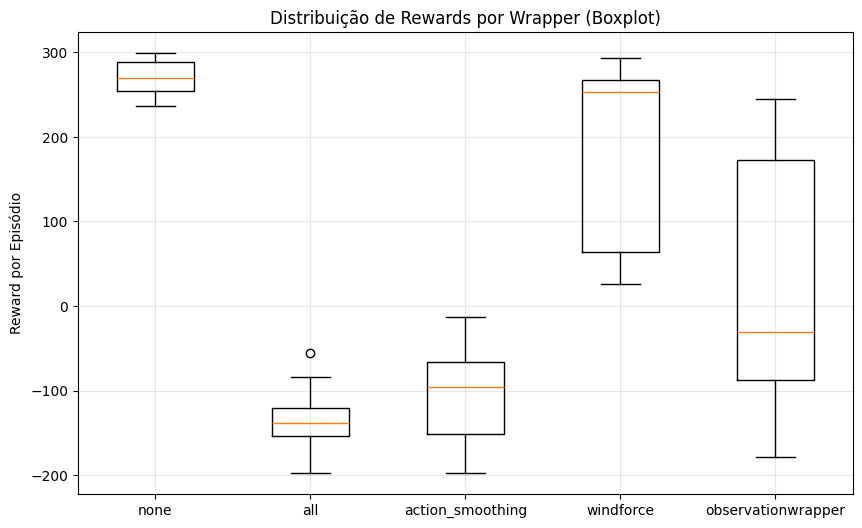

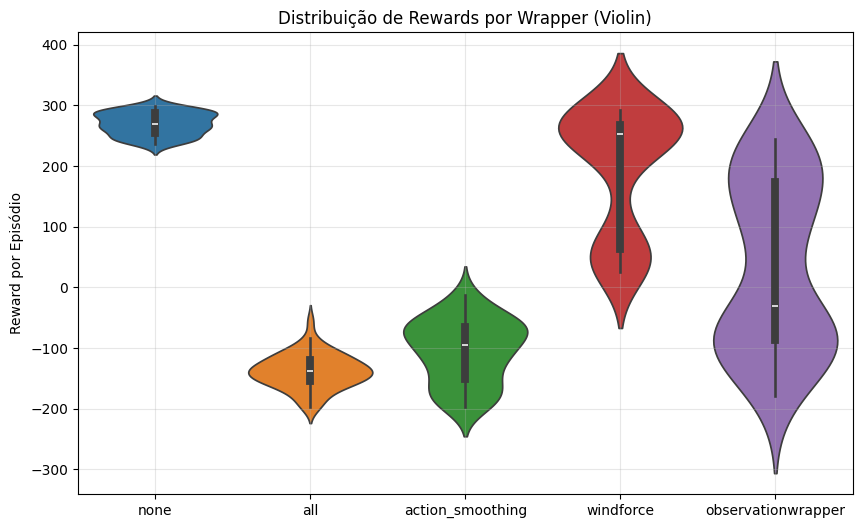

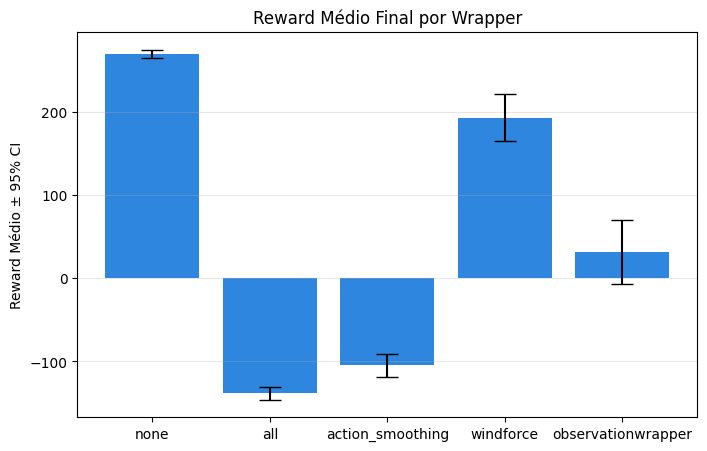

C:\Users\Admin\AppData\Local\Temp\ipykernel_15624\3953025772.py:67: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


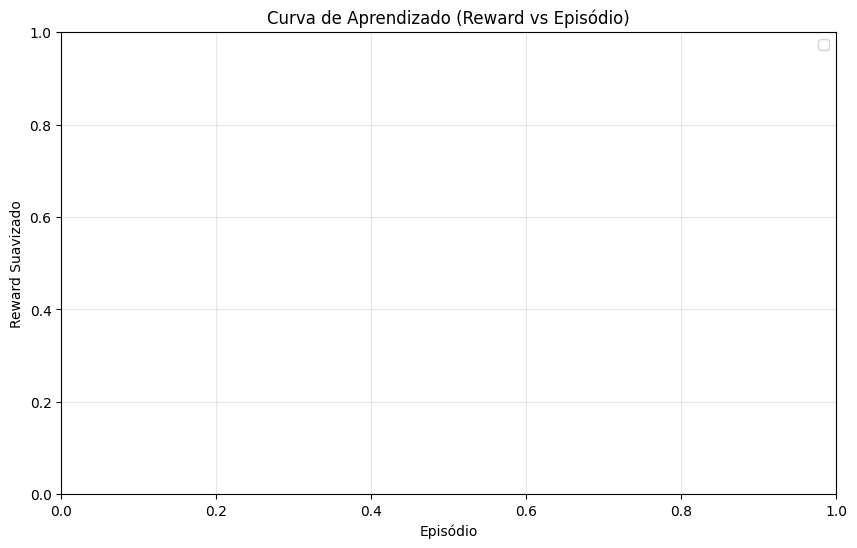

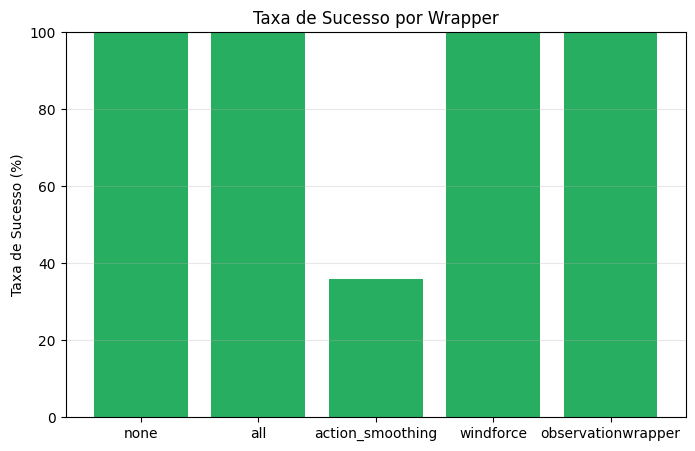


Tabela Resumo das Métricas Finais por Wrapper:


,Wrapper,Reward Médio,Reward Std,Reward Mediana,IQR,Taxa Sucesso (%)
0,none,269.635216,18.425774,269.252850,33.432500,100.0
1,all,-138.167698,28.077113,-138.099107,33.279787,100.0
2,action_smoothing,-104.900271,51.742942,-95.745630,85.450777,36.0
3,windforce,193.062071,100.660743,252.505770,203.568557,100.0
4,observationwrapper,31.168802,138.128798,-30.961176,260.185204,100.0


In [ ]:
wrapper_names = []
all_rewards = []
success_rates = []
mean_rewards = []
n_episodes = 50  # ajustar se necessário

# Reorganiza os resultados
for wrapper_name, result in results_wrappers:
    metrics = result['metrics']
    wrapper_names.append(wrapper_name)
    all_rewards.append(metrics['per_episode'])
    success_rates.append(metrics['success_rate'] * 100)
    mean_rewards.append(metrics['mean_reward'])

# ============================
# 1️⃣ Boxplot de Rewards por Wrapper
# ============================
plt.figure(figsize=(10,6))
plt.boxplot(all_rewards, labels=wrapper_names, showfliers=True)
plt.ylabel("Reward por Episódio")
plt.title("Distribuição de Rewards por Wrapper (Boxplot)")
plt.grid(alpha=0.3)
plt.show()

# ============================
# 2️⃣ Violin plot (opcional, mais visual)
# ============================
plt.figure(figsize=(10,6))
sns.violinplot(data=all_rewards)
plt.xticks(range(len(wrapper_names)), wrapper_names)
plt.ylabel("Reward por Episódio")
plt.title("Distribuição de Rewards por Wrapper (Violin)")
plt.grid(alpha=0.3)
plt.show()

# ============================
# 3️⃣ Reward Médio ± 95% CI
# ============================
plt.figure(figsize=(8,5))
mean_rewards_arr = np.array([np.mean(r) for r in all_rewards])
std_rewards_arr = np.array([np.std(r) for r in all_rewards])
ci95 = 1.96 * std_rewards_arr / np.sqrt(n_episodes)

plt.bar(wrapper_names, mean_rewards_arr, yerr=ci95, capsize=8, color='#2E86DE')
plt.ylabel("Reward Médio ± 95% CI")
plt.title("Reward Médio Final por Wrapper")
plt.grid(axis='y', alpha=0.3)
plt.show()


# ============================
# 5️⃣ Success Rate (%) por Wrapper
# ============================
plt.figure(figsize=(8,5))
plt.bar(wrapper_names, success_rates, color='#27AE60')
plt.ylabel('Taxa de Sucesso (%)')
plt.title('Taxa de Sucesso por Wrapper')
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)
plt.show()

# ============================
# 6️⃣ Tabela Resumo com Mediana e IQR
# ============================
summary_df = pd.DataFrame({
    'Wrapper': wrapper_names,
    'Reward Médio': mean_rewards_arr,
    'Reward Std': std_rewards_arr,
    'Reward Mediana': [np.median(r) for r in all_rewards],
    'IQR': [np.percentile(r, 75) - np.percentile(r, 25) for r in all_rewards],
    'Taxa Sucesso (%)': success_rates
})
print("\nTabela Resumo das Métricas Finais por Wrapper:")
display(summary_df)